# PyTorch Workflow

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
print(torch.__version__)

2.11.0+cpu


# 1.Data (Preparing and loading)

In [2]:
weight=01.7
bias=0.3

start=0
end=1
step=0.02
x=torch.arange(start,end,step)
y=weight*x+bias

x[:10],y[:10]

(tensor([0.0000, 0.0200, 0.0400, 0.0600, 0.0800, 0.1000, 0.1200, 0.1400, 0.1600,
         0.1800]),
 tensor([0.3000, 0.3340, 0.3680, 0.4020, 0.4360, 0.4700, 0.5040, 0.5380, 0.5720,
         0.6060]))

#2.split data into training and test set

In [3]:
from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, shuffle=True
)

In [4]:
def plot_predictions(train_data=x_train,
                     train_labels=y_train,
                     test_data=x_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

In [5]:
plot_predictions

<function __main__.plot_predictions(train_data=tensor([0.2400, 0.0800, 0.7400, 0.1600, 0.0600, 0.1200, 0.8200, 0.9200, 0.9400,
        0.3000, 0.1800, 0.3200, 0.4800, 0.6800, 0.6200, 0.0000, 0.8800, 0.5400,
        0.6600, 0.1000, 0.5800, 0.2200, 0.7200, 0.0200, 0.4200, 0.0400, 0.8600,
        0.7000, 0.4600, 0.8000, 0.2000, 0.4400, 0.3600, 0.9800, 0.4000, 0.1400,
        0.8400, 0.2800, 0.5600, 0.7600]), train_labels=tensor([0.7080, 0.4360, 1.5580, 0.5720, 0.4020, 0.5040, 1.6940, 1.8640, 1.8980,
        0.8100, 0.6060, 0.8440, 1.1160, 1.4560, 1.3540, 0.3000, 1.7960, 1.2180,
        1.4220, 0.4700, 1.2860, 0.6740, 1.5240, 0.3340, 1.0140, 0.3680, 1.7620,
        1.4900, 1.0820, 1.6600, 0.6400, 1.0480, 0.9120, 1.9660, 0.9800, 0.5380,
        1.7280, 0.7760, 1.2520, 1.5920]), test_data=tensor([0.2600, 0.7800, 0.6000, 0.9000, 0.3400, 0.9600, 0.5200, 0.5000, 0.6400,
        0.3800]), test_labels=tensor([0.7420, 1.6260, 1.3200, 1.8300, 0.8780, 1.9320, 1.1840, 1.1500, 1.3880,
        0.9460]), predictions=None)>

# 3.Build model

In [6]:

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                                dtype=torch.float),
                                   requires_grad=True)

        self.bias = nn.Parameter(torch.randn(1,
                                            dtype=torch.float),
                                requires_grad=True)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

In [7]:
torch.manual_seed(42)

model_0=LinearRegressionModel()
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [8]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [9]:
with torch.inference_mode():
  y_pred=model_0(x_test)


In [10]:
print(f"Number of testing samples: {len(x_test)}")
print(f"Number of predictions made: {len(y_pred)}")
print(f"Predicted values:\n{y_pred}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([0.2163, 0.3914, 0.3308, 0.4318, 0.2433, 0.4520, 0.3039, 0.2972, 0.3443,
        0.2568])


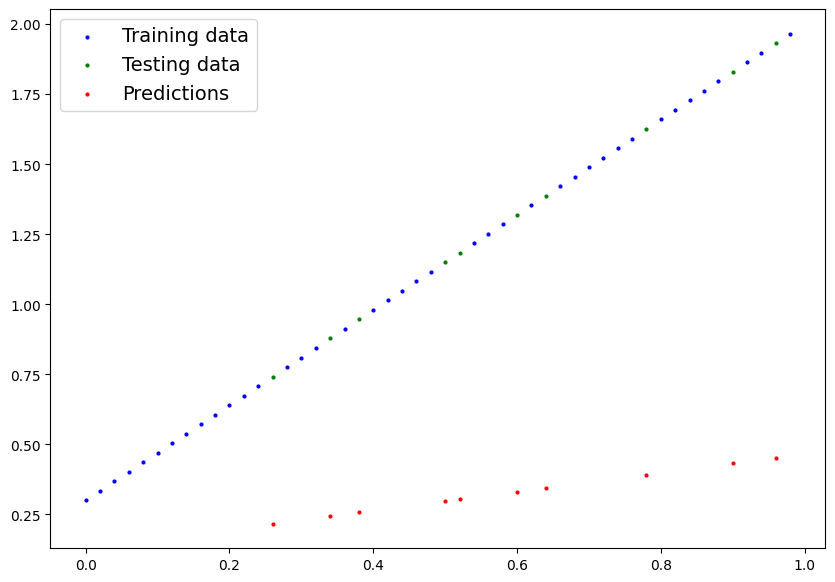

In [11]:
plot_predictions(predictions=y_pred)

In [12]:
y_test - y_pred

tensor([0.5257, 1.2346, 0.9892, 1.3982, 0.6347, 1.4800, 0.8801, 0.8528, 1.0437,
        0.6892])

#4. Train model

In [13]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

In [16]:
torch.manual_seed(42)
epochs=100

epoch_count=[]
loss_values=[]
test_loss_values=[]

for epoch in range(epochs):
  model_0.train()
  y_pred=model_0(x_train)
  loss=loss_fn(y_pred,y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_0.eval()
  with torch.inference_mode():
     test_pred=model_0(x_test)
     test_loss=loss_fn(test_pred,y_test)


  if epoch %10==0:
     epoch_count.append(epoch)
     loss_values.append(loss)
     test_loss_values.append(test_loss)
     print(f"Epoch: {epoch} | Loss: {loss:.4f} | Test loss: {test_loss:.4f}")




Epoch: 0 | Loss: 0.8058 | Test loss: 0.9601
Epoch: 10 | Loss: 0.6841 | Test loss: 0.8327
Epoch: 20 | Loss: 0.5650 | Test loss: 0.7073
Epoch: 30 | Loss: 0.4737 | Test loss: 0.5978
Epoch: 40 | Loss: 0.4084 | Test loss: 0.5056
Epoch: 50 | Loss: 0.3619 | Test loss: 0.4287
Epoch: 60 | Loss: 0.3291 | Test loss: 0.3652
Epoch: 70 | Loss: 0.3029 | Test loss: 0.3165
Epoch: 80 | Loss: 0.2834 | Test loss: 0.2778
Epoch: 90 | Loss: 0.2677 | Test loss: 0.2475


#Loss Curve Plotting

/tmp/ipykernel_3492/983485247.py:2: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.plot(epoch_count,np.array(torch.tensor(loss_values).numpy()),label="Train loss")


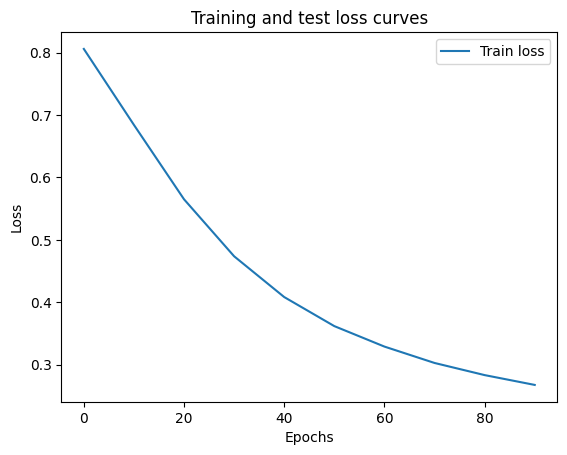

In [18]:
import numpy as np
plt.plot(epoch_count,np.array(torch.tensor(loss_values).numpy()),label="Train loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

#5.Inference/Evaluating

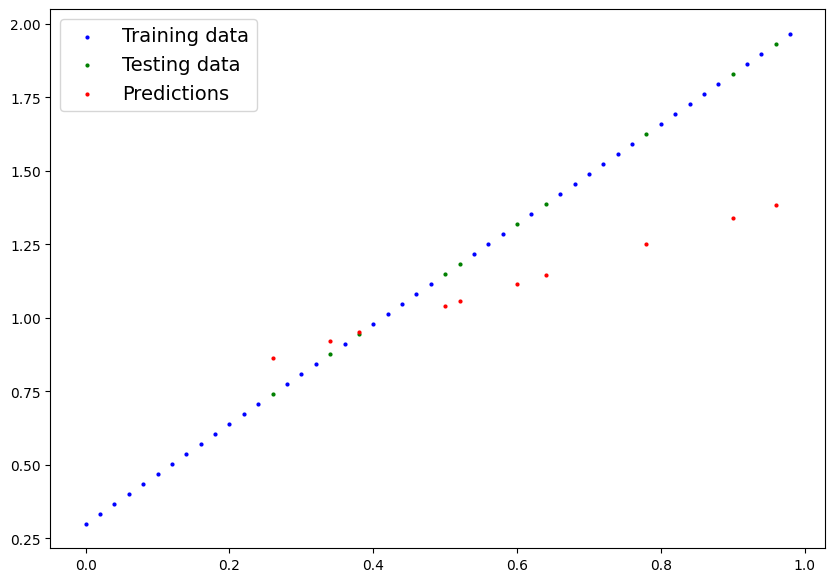

In [20]:
with torch.inference_mode():
  y_preds_new=model_0(x_test)
plot_predictions(predictions=y_preds_new)

#6.Saving & Loading Model

In [21]:
from IPython.utils import module_paths
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME="01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)


Saving model to: models/01_pytorch_workflow_model_0.pth


#Loading

In [22]:
loaded_models_0=LinearRegressionModel()

loaded_models_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

loaded_models_0.eval()
with torch.inference_mode():
  loaded_model_preds=loaded_models_0(x_test)
y_preds_new == loaded_model_preds

tensor([True, True, True, True, True, True, True, True, True, True])

#7.Putting it all together

In [30]:
import torch
from torch import nn
import matplotlib.pyplot as plt

weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=1, out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

torch.manual_seed(42)
model_1 = LinearRegressionModelV2().to(device)

loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.01)

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

epochs = 200
for epoch in range(epochs):
    model_1.train()
    y_pred = model_1(X_train)
    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        model_1.eval()
        with torch.inference_mode():
            test_pred = model_1(X_test)
            test_loss = loss_fn(test_pred, y_test)
        print(f"Epoch: {epoch} | Train Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")

Using device: cpu
Epoch: 0 | Train Loss: 0.5552 | Test Loss: 0.5740
Epoch: 20 | Train Loss: 0.3248 | Test Loss: 0.3046
Epoch: 40 | Train Loss: 0.0943 | Test Loss: 0.0351
Epoch: 60 | Train Loss: 0.0200 | Test Loss: 0.0458
Epoch: 80 | Train Loss: 0.0131 | Test Loss: 0.0299
Epoch: 100 | Train Loss: 0.0062 | Test Loss: 0.0141
Epoch: 120 | Train Loss: 0.0013 | Test Loss: 0.0138
Epoch: 140 | Train Loss: 0.0013 | Test Loss: 0.0138
Epoch: 160 | Train Loss: 0.0013 | Test Loss: 0.0138
Epoch: 180 | Train Loss: 0.0013 | Test Loss: 0.0138
